In [1]:
import os,sys
# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar)
from util.ml_framework import (cnn, vae)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim, interplevel, to_np,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
import proplot as plot
from proc_vars import get_precip_class, area_stats
from metpy.units import units

/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
! pwd

/glade/work/ihtam/wrf-stuff/analysis/notebooks/haiyan_sen


In [2]:
def read_from_pickle(path):
    with open(path, 'rb') as file:
        try:
            while True:
                return pickle.load(file)
        except EOFError:
            pass

In [3]:
def proc_pickles(memb07sen_path,memb03sen_path,oldensm_path):
    # Read in Memb07 sensitivity experiments
    memb07sen_mslp_pd = pd.DataFrame([read_from_pickle(memb07sen_path)[name] for name in ['ctrl','mdd_p2f','dd_p2f']]).transpose()
    # Read in Memb03 sensitivity exxperiments
    memb03sen_mslp_pd = pd.DataFrame([read_from_pickle(memb03sen_path)[name] for name in ['ctrl','miaxi2x','aiaxi2x','mdd_p2f','dd_p2f']]).transpose()
    # For oldensm, interpolate memb02 and throw out memb10 (for now)
    TEST = read_from_pickle(oldensm_path)
    interp_memb02 = pd.DataFrame(TEST['memb02']).interpolate().values.transpose()
    TEST['memb02'] = [float(obj) for obj in interp_memb02[0]]
    oldensm_mslp_pd = pd.DataFrame([TEST[f'memb{exp}'] for exp in ['01','02','03','04','05','06','07','08','09']]).transpose()
    # Merge dataframes
    allexp_pd = pd.concat(
        [memb07sen_mslp_pd.reset_index(drop=True),
         memb03sen_mslp_pd.reset_index(drop=True),
         oldensm_mslp_pd.reset_index(drop=True)],
        axis=1
    )
    return allexp_pd.interpolate()

In [4]:
allmslp = proc_pickles(f"./store/haiyansen_memb07_slp.pkl",f"./store/haiyansen_memb03_slp.pkl",f"./store/haiyan_oldensm_slp.pkl")
alllconv = proc_pickles(f"./store/haiyansen_memb07_lconv.pkl",f"./store/haiyansen_memb03_lconv.pkl",f"./store/haiyan_oldensm_lconv.pkl")
alllvort = proc_pickles(f"./store/haiyansen_memb07_lvort.pkl",f"./store/haiyansen_memb03_lvort.pkl",f"./store/haiyan_oldensm_lvort.pkl")
allmvort = proc_pickles(f"./store/haiyansen_memb07_mvort.pkl",f"./store/haiyansen_memb03_mvort.pkl",f"./store/haiyan_oldensm_mvort.pkl")
alllvapor = proc_pickles(f"./store/haiyansen_memb07_lvapor.pkl",f"./store/haiyansen_memb03_lvapor.pkl",f"./store/haiyan_oldensm_lvapor.pkl")
allmvapor = proc_pickles(f"./store/haiyansen_memb07_mvapor.pkl",f"./store/haiyansen_memb03_mvapor.pkl",f"./store/haiyan_oldensm_mvapor.pkl")
allmwa_mean = proc_pickles(f"./store/haiyansen_memb07_mwa_mean.pkl",f"./store/haiyansen_memb03_mwa_mean.pkl",f"./store/haiyan_oldensm_mwa_mean.pkl")
allulw = proc_pickles(f"./store/haiyansen_memb07_ulw.pkl",f"./store/haiyansen_memb03_ulw.pkl",f"./store/haiyan_oldensm_ulw.pkl")
allmlw = proc_pickles(f"./store/haiyansen_memb07_mlw.pkl",f"./store/haiyansen_memb03_mlw.pkl",f"./store/haiyan_oldensm_mlw.pkl")

In [5]:
def lag_corr(x, y, lags):
    r = []
    for lag in lags:
        if lag > 0:
            xs = x[:-lag]
            ys = y[lag:]
        elif lag < 0:
            xs = x[-lag:]
            ys = y[:lag]
        else:
            xs = x
            ys = y
        r.append(np.corrcoef(xs, ys)[0,1])
    return np.array(r)

def calc_lag(var,target,lags):
    expMSLP = target.values
    expLVORT = var.values
    dMSLP = (expMSLP[6:]-expMSLP[:-6])/6

    mslp_std = (dMSLP - dMSLP.mean()) / dMSLP.std()
    lvort_std = (expLVORT[:-6] - expLVORT[:-6].mean()) / expLVORT[:-6].std()
    r = lag_corr(lvort_std,mslp_std,lags)
    return r

In [6]:
lags = np.arange(-12, 13)
r_lvort = [calc_lag(alllvort.iloc[:,i],allmslp.iloc[:,i],lags) for i in range(17)]
r_mvort = [calc_lag(allmvort.iloc[:,i],allmslp.iloc[:,i],lags) for i in range(17)]
r_mwa_mean = [calc_lag(allmwa_mean.iloc[:,i],allmslp.iloc[:,i],lags) for i in range(17)]
r_lconv = [calc_lag(alllconv.iloc[:,i],allmslp.iloc[:,i],lags) for i in range(17)]

In [7]:
r_mvortlvort = [calc_lag(allmvort.iloc[:,i],alllvort.iloc[:,i],lags) for i in range(17)]
r_mwa_mvort = [calc_lag(allmwa_mean.iloc[:,i],allmvort.iloc[:,i],lags) for i in range(17)]
r_mwa_lvort = [calc_lag(allmwa_mean.iloc[:,i],alllvort.iloc[:,i],lags) for i in range(17)]
r_mvapor_mvort = [calc_lag(allmvapor.iloc[:,i],allmvort.iloc[:,i],lags) for i in range(17)]
r_lvapor_mvort = [calc_lag(alllvapor.iloc[:,i],allmvort.iloc[:,i],lags) for i in range(17)]
r_lconv_lvort = [calc_lag(alllconv.iloc[:,i],alllvort.iloc[:,i],lags) for i in range(17)]

In [25]:
r_mlw_mvort = [calc_lag(allmlw.iloc[:,i],allmvort.iloc[:,i],lags) for i in range(17)]
r_ulw_mvort = [calc_lag(allulw.iloc[:,i],allmvort.iloc[:,i],lags) for i in range(17)]
r_mlw_lvort = [calc_lag(allmlw.iloc[:,i],alllvort.iloc[:,i],lags) for i in range(17)]
r_ulw_lvort = [calc_lag(allulw.iloc[:,i],alllvort.iloc[:,i],lags) for i in range(17)]

In [9]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 9,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_77343/1532609950.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


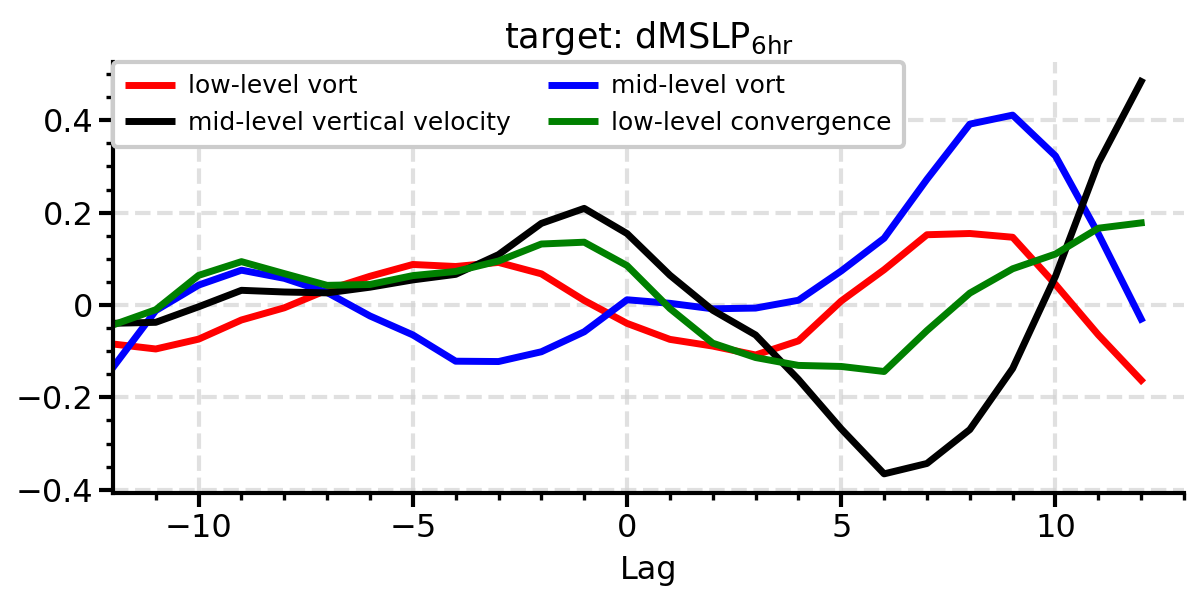

In [11]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(lags,np.asarray(r_lvort).mean(axis=0),c='r',lw=2.5,label='low-level vort')
axs.plot(lags,np.asarray(r_mvort).mean(axis=0),c='b',lw=2.5,label='mid-level vort')
axs.plot(lags,np.asarray(r_mwa_mean).mean(axis=0),c='k',lw=2.5,label='mid-level vertical velocity')
axs.plot(lags,np.asarray(r_lconv).mean(axis=0),c='green',lw=2.5,label='low-level convergence')
axs.format(xlim=(-12,13),
           xlabel='Lag', title='target: dMSLP$_{6hr}$')
plt.legend(loc=1,ncols=2)
plt.savefig('./pics/laggedcorr_dmslp.png',dpi=400)
plt.show()

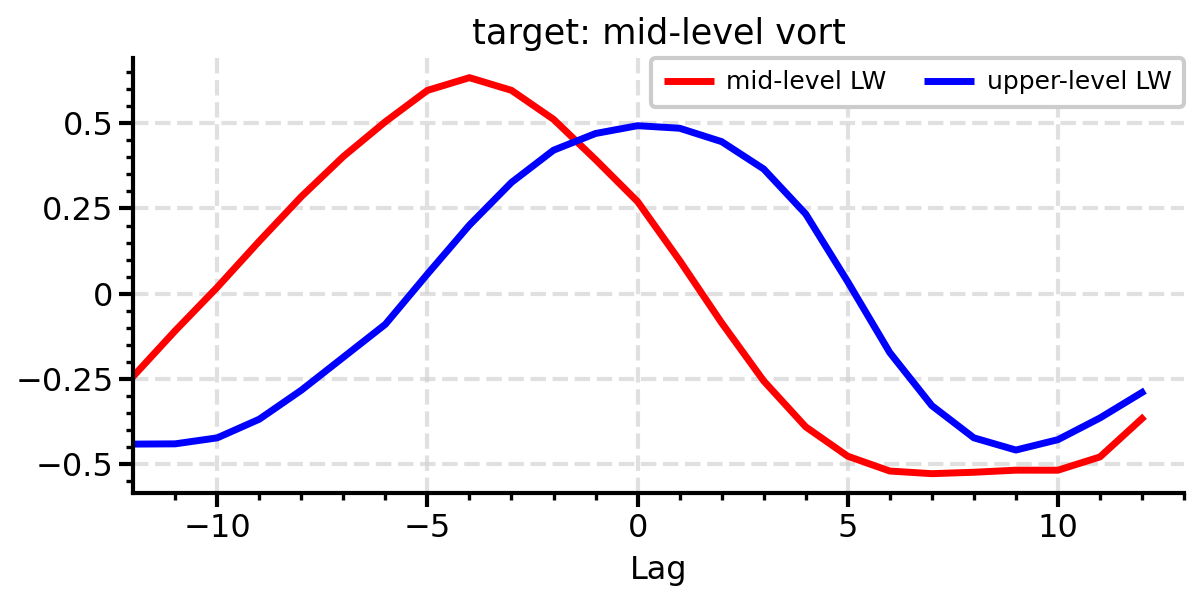

In [13]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(lags,np.asarray(r_mlw_mvort).mean(axis=0),c='r',lw=2.5,label='mid-level LW')
axs.plot(lags,np.asarray(r_ulw_mvort).mean(axis=0),c='b',lw=2.5,label='upper-level LW')
axs.format(xlim=(-12,13),
           xlabel='Lag', title='target: mid-level vort')
plt.legend(loc=1,ncols=2)
#plt.savefig('./pics/laggedcorr_dmslp.png',dpi=400)
plt.show()

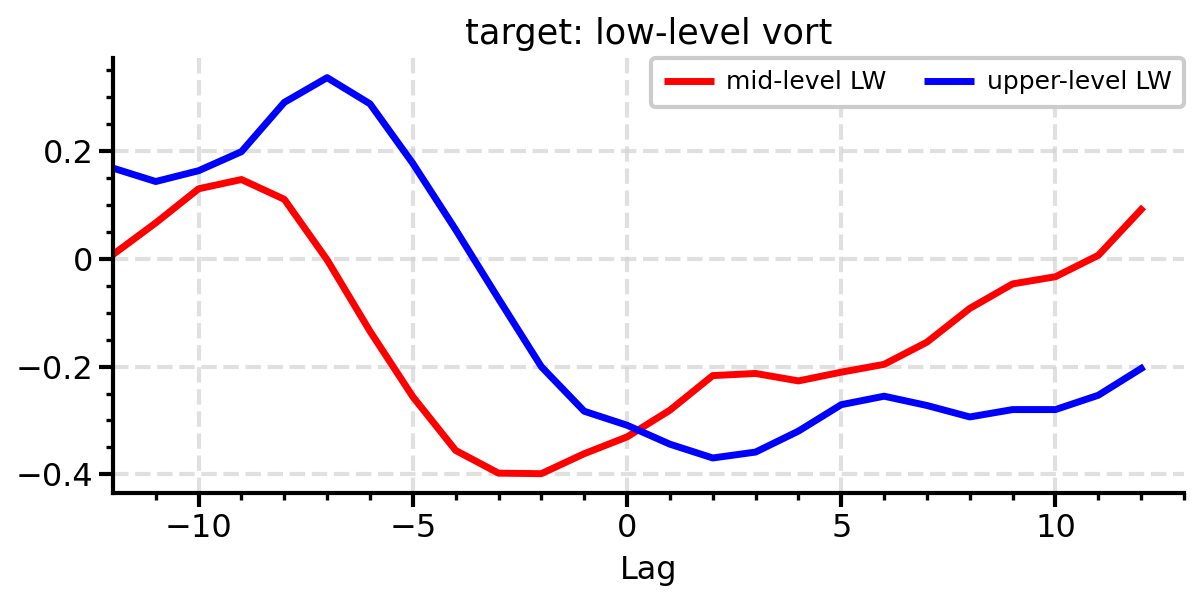

In [26]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(lags,np.asarray(r_mlw_lvort).mean(axis=0),c='r',lw=2.5,label='mid-level LW')
axs.plot(lags,np.asarray(r_ulw_lvort).mean(axis=0),c='b',lw=2.5,label='upper-level LW')
axs.format(xlim=(-12,13),
           xlabel='Lag', title='target: low-level vort')
plt.legend(loc=1,ncols=2)
#plt.savefig('./pics/laggedcorr_dmslp.png',dpi=400)
plt.show()

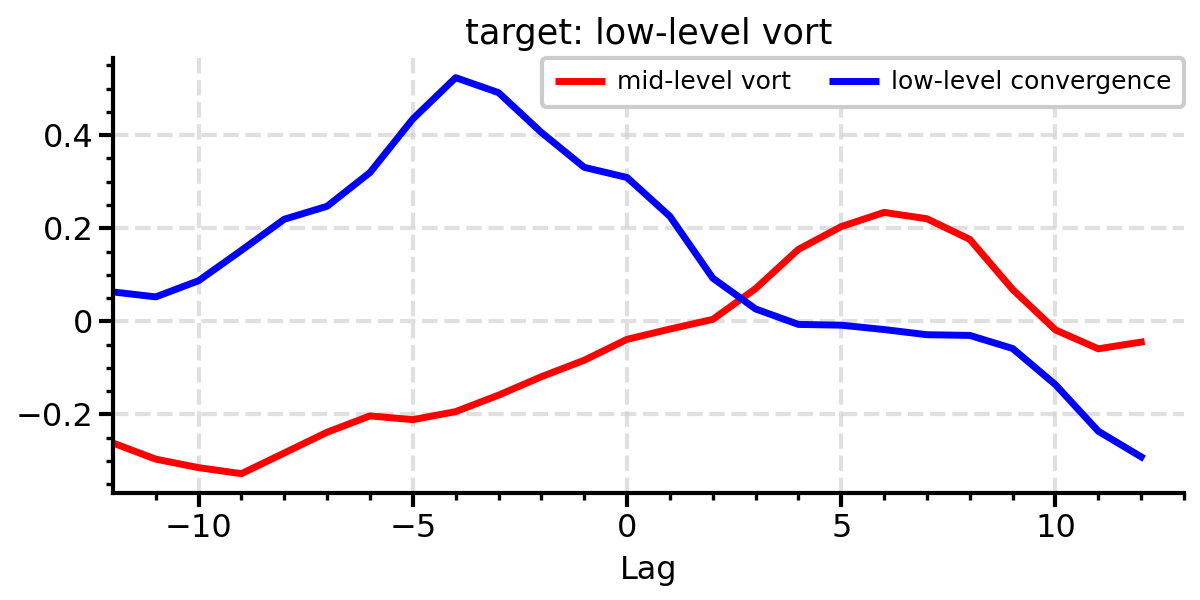

In [38]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(lags,np.asarray(r_mvortlvort).mean(axis=0),c='r',lw=2.5,label='mid-level vort')
axs.plot(lags,np.asarray(r_lconv_lvort).mean(axis=0),c='b',lw=2.5,label='low-level convergence')
axs.format(xlim=(-12,13),
           xlabel='Lag', title='target: low-level vort')
plt.legend(loc=1,ncols=2)
#plt.savefig('./pics/laggedcorr_dmslp.png',dpi=400)
plt.show()

## Granger

In [16]:
class causal_testing:
    def __init__(self,target,var):
        expMSLP = target.values
        self.target = (expMSLP[6:]-expMSLP[:-6])/6
        self.var = var.values
        self.norm_target = (self.target - self.target.mean()) / self.target.std()
        self.norm_var = (self.var[:-6] - self.var[:-6].mean()) / self.var[:-6].std()
    def get_norm_stuff(self):
        return self.norm_target,self.norm_var

In [17]:
def get_proc_data(target,var):
    norm_targets,norm_vars = [],[]
    for i in range(17):
        temp = causal_testing(target.iloc[:,i],var.iloc[:,i]).get_norm_stuff()
        norm_targets.append(temp[0])
        norm_vars.append(temp[1])
    return norm_targets,norm_vars

In [18]:
norm_MSLP,norm_lvort = get_proc_data(allmslp, alllvort)
_, norm_mvort = get_proc_data(allmslp, allmvort)
_, norm_lconv = get_proc_data(allmslp, alllconv)
_, norm_mlw = get_proc_data(allmslp, allmlw)
_, norm_ulw = get_proc_data(allmslp, allulw)

In [19]:
df_stacked = pd.DataFrame({
    "dMSLP": np.concatenate(norm_MSLP),
    "zeta_low": np.concatenate(norm_lvort),
    "zeta_mid": np.concatenate(norm_mvort),
    "conv_low": np.concatenate(norm_lconv),
    "lw_upper": np.concatenate(norm_ulw),
    "lw_mid": np.concatenate(norm_mlw)
})

In [20]:
from statsmodels.tsa.stattools import grangercausalitytests
data = df_stacked[['dMSLP','zeta_low']]
grangercausalitytests(data, maxlag=1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=8.4988  , p=0.0038  , df_denom=387, df_num=1
ssr based chi2 test:   chi2=8.5647  , p=0.0034  , df=1
likelihood ratio test: chi2=8.4720  , p=0.0036  , df=1
parameter F test:         F=8.4988  , p=0.0038  , df_denom=387, df_num=1


{1: ({'ssr_ftest': (8.498786588909669, 0.0037605248587891625, 387.0, 1),
   'ssr_chi2test': (8.564668655490363, 0.0034274934834210686, 1),
   'lrtest': (8.471980190703448, 0.003606586073434558, 1),
   'params_ftest': (8.49878658890976, 0.003760524858788955, 387.0, 1.0)},
   array([[0., 1., 0.]])])}

In [24]:
data = df_stacked[['dMSLP','zeta_mid']]
grangercausalitytests(data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3188  , p=0.5726  , df_denom=387, df_num=1
ssr based chi2 test:   chi2=0.3213  , p=0.5708  , df=1
likelihood ratio test: chi2=0.3212  , p=0.5709  , df=1
parameter F test:         F=0.3188  , p=0.5726  , df_denom=387, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2713  , p=0.7625  , df_denom=384, df_num=2
ssr based chi2 test:   chi2=0.5497  , p=0.7597  , df=2
likelihood ratio test: chi2=0.5493  , p=0.7599  , df=2
parameter F test:         F=0.2713  , p=0.7625  , df_denom=384, df_num=2


{1: ({'ssr_ftest': (0.3188300443391938, 0.5726387244534985, 387.0, 1),
   'ssr_chi2test': (0.3213015950705054, 0.5708264819943205, 1),
   'lrtest': (0.32116931551945527, 0.5709057751407864, 1),
   'params_ftest': (0.31883004433929885, 0.5726387244534208, 387.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.2712930461365631, 0.7625390489737063, 384.0, 2),
   'ssr_chi2test': (0.5496510153495991, 0.7597046742951433, 2),
   'lrtest': (0.5492630565455556, 0.7598520556475875, 2),
   'params_ftest': (0.27129304613658367, 0.7625390489737063, 384.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In [27]:
data = df_stacked[['zeta_low','zeta_mid']]
grangercausalitytests(data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0024  , p=0.9610  , df_denom=387, df_num=1
ssr based chi2 test:   chi2=0.0024  , p=0.9608  , df=1
likelihood ratio test: chi2=0.0024  , p=0.9608  , df=1
parameter F test:         F=0.0024  , p=0.9610  , df_denom=387, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.4316  , p=0.0333  , df_denom=384, df_num=2
ssr based chi2 test:   chi2=6.9525  , p=0.0309  , df=2
likelihood ratio test: chi2=6.8911  , p=0.0319  , df=2
parameter F test:         F=3.4316  , p=0.0333  , df_denom=384, df_num=2


{1: ({'ssr_ftest': (0.0023930640461510486, 0.9610091201383902, 387.0, 1),
   'ssr_chi2test': (0.0024116149302297386, 0.9608330716977768, 1),
   'lrtest': (0.0024116074739595206, 0.9608331321976387, 1),
   'params_ftest': (0.002393064046190287, 0.9610091201380405, 387.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (3.4315836711908063, 0.03333064027968157, 384.0, 2),
   'ssr_chi2test': (6.95253150048554, 0.03092266866638092, 2),
   'lrtest': (6.891131305584963, 0.03188672012807583, 2),
   'params_ftest': (3.4315836711908387, 0.03333064027968036, 384.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In [52]:
data = df_stacked[['dMSLP','conv_low']]
grangercausalitytests(data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=9.1432  , p=0.0027  , df_denom=387, df_num=1
ssr based chi2 test:   chi2=9.2140  , p=0.0024  , df=1
likelihood ratio test: chi2=9.1069  , p=0.0025  , df=1
parameter F test:         F=9.1432  , p=0.0027  , df_denom=387, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.3625  , p=0.0955  , df_denom=384, df_num=2
ssr based chi2 test:   chi2=4.7866  , p=0.0913  , df=2
likelihood ratio test: chi2=4.7574  , p=0.0927  , df=2
parameter F test:         F=2.3625  , p=0.0955  , df_denom=384, df_num=2


{1: ({'ssr_ftest': (9.143155459580106, 0.0026628643256321628, 387.0, 1),
   'ssr_chi2test': (9.214032633685378, 0.0024016708139504607, 1),
   'lrtest': (9.106873067679544, 0.0025465081818583863, 1),
   'params_ftest': (9.143155459580088, 0.0026628643256321628, 387.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (2.3625237584083054, 0.09554989572576006, 384.0, 2),
   'ssr_chi2test': (4.786571573025161, 0.0913291023917969, 2),
   'lrtest': (4.757362011172745, 0.09267273174772599, 2),
   'params_ftest': (2.3625237584083756, 0.09554989572575229, 384.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In [53]:
data = df_stacked[['zeta_low','conv_low']]
grangercausalitytests(data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=19.0061 , p=0.0000  , df_denom=387, df_num=1
ssr based chi2 test:   chi2=19.1534 , p=0.0000  , df=1
likelihood ratio test: chi2=18.6979 , p=0.0000  , df=1
parameter F test:         F=19.0061 , p=0.0000  , df_denom=387, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=9.2630  , p=0.0001  , df_denom=384, df_num=2
ssr based chi2 test:   chi2=18.7672 , p=0.0001  , df=2
likelihood ratio test: chi2=18.3286 , p=0.0001  , df=2
parameter F test:         F=9.2630  , p=0.0001  , df_denom=384, df_num=2


{1: ({'ssr_ftest': (19.006056223808866, 1.672308748564854e-05, 387.0, 1),
   'ssr_chi2test': (19.15338999298568, 1.2062308202403705e-05, 1),
   'lrtest': (18.697919474561786, 1.5314949890936236e-05, 1),
   'params_ftest': (19.006056223808827, 1.672308748564854e-05, 387.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (9.263008845887573, 0.00011780274053842352, 384.0, 2),
   'ssr_chi2test': (18.767241880470134, 8.409016514320144e-05, 2),
   'lrtest': (18.328583957418005, 0.000104712508353476, 2),
   'params_ftest': (9.263008845887612, 0.0001178027405384185, 384.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In [37]:
data = df_stacked[['zeta_low','lw_mid']]
grangercausalitytests(data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=17.0199 , p=0.0000  , df_denom=387, df_num=1
ssr based chi2 test:   chi2=17.1519 , p=0.0000  , df=1
likelihood ratio test: chi2=16.7854 , p=0.0000  , df=1
parameter F test:         F=17.0199 , p=0.0000  , df_denom=387, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.7350  , p=0.0013  , df_denom=384, df_num=2
ssr based chi2 test:   chi2=13.6454 , p=0.0011  , df=2
likelihood ratio test: chi2=13.4115 , p=0.0012  , df=2
parameter F test:         F=6.7350  , p=0.0013  , df_denom=384, df_num=2


{1: ({'ssr_ftest': (17.019939486214618, 4.5310223570739916e-05, 387.0, 1),
   'ssr_chi2test': (17.151877001611627, 3.450682586388937e-05, 1),
   'lrtest': (16.78542016216261, 4.1853644059741534e-05, 1),
   'params_ftest': (17.019939486214742, 4.5310223570738066e-05, 387.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (6.735005769740127, 0.0013340021622580032, 384.0, 2),
   'ssr_chi2test': (13.645402314733907, 0.0010887759914190627, 2),
   'lrtest': (13.411528101177737, 0.0012238372730450134, 2),
   'params_ftest': (6.735005769740202, 0.001334002162257893, 384.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In [33]:
data = df_stacked[['zeta_low','lw_mid']]
grangercausalitytests(data, maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=17.0199 , p=0.0000  , df_denom=387, df_num=1
ssr based chi2 test:   chi2=17.1519 , p=0.0000  , df=1
likelihood ratio test: chi2=16.7854 , p=0.0000  , df=1
parameter F test:         F=17.0199 , p=0.0000  , df_denom=387, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.7350  , p=0.0013  , df_denom=384, df_num=2
ssr based chi2 test:   chi2=13.6454 , p=0.0011  , df=2
likelihood ratio test: chi2=13.4115 , p=0.0012  , df=2
parameter F test:         F=6.7350  , p=0.0013  , df_denom=384, df_num=2


{1: ({'ssr_ftest': (17.019939486214618, 4.5310223570739916e-05, 387.0, 1),
   'ssr_chi2test': (17.151877001611627, 3.450682586388937e-05, 1),
   'lrtest': (16.78542016216261, 4.1853644059741534e-05, 1),
   'params_ftest': (17.019939486214742, 4.5310223570738066e-05, 387.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (6.735005769740127, 0.0013340021622580032, 384.0, 2),
   'ssr_chi2test': (13.645402314733907, 0.0010887759914190627, 2),
   'lrtest': (13.411528101177737, 0.0012238372730450134, 2),
   'params_ftest': (6.735005769740202, 0.001334002162257893, 384.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])])}

In [55]:
df = df_stacked.copy()

# create lag-1 variables
df['dMSLP_l1']   = df['dMSLP'].shift(1)
df['zlow_l1']    = df['zeta_low'].shift(1)
df['conv_l1']    = df['conv_low'].shift(1)

df = df.dropna()

import statsmodels.api as sm

X1 = df[['dMSLP_l1', 'zlow_l1']]
X1 = sm.add_constant(X1)

model1 = sm.OLS(df['dMSLP'], X1).fit()
print(model1.summary())

X2 = df[['dMSLP_l1', 'zlow_l1', 'conv_l1']]
X2 = sm.add_constant(X2)

model2 = sm.OLS(df['dMSLP'], X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  dMSLP   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     237.7
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           4.70e-68
Time:                        07:21:17   Log-Likelihood:                -395.71
No. Observations:                 390   AIC:                             797.4
Df Residuals:                     387   BIC:                             809.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0041      0.034      0.119      0.9

In [56]:
df = df_stacked.copy()

# create lag-1 variables
df['dMSLP_l1']   = df['dMSLP'].shift(1)
df['zlow_l1']    = df['zeta_low'].shift(1)
df['conv_l1']    = df['conv_low'].shift(1)

df = df.dropna()

import statsmodels.api as sm

X1 = df[['zlow_l1', 'conv_low']]
X1 = sm.add_constant(X1)

model1 = sm.OLS(df['zeta_low'], X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               zeta_low   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     347.7
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           3.69e-87
Time:                        07:30:31   Log-Likelihood:                -353.32
No. Observations:                 390   AIC:                             712.6
Df Residuals:                     387   BIC:                             724.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0038      0.030     -0.124      0.9